<a href="https://colab.research.google.com/github/sidraibrar69-create/Stock-Price-Prediction/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
stock_data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2024-01-01"
)

/tmp/ipykernel_3387/618581572.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  1 of 1 completed


In [4]:
print(stock_data.head())

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201401  72.239935  70.503539  70.754006  118387200
2020-01-07  71.861862  72.466345  71.642704  72.211064  108872000
2020-01-08  73.017853  73.318893  71.565636  71.565636  132079200


In [5]:
stock_data["Next_Close"] = stock_data["Close"].shift(-1)

In [6]:
stock_data.dropna(inplace=True)

In [7]:
X = stock_data[["Open", "High", "Low", "Volume"]]

In [8]:
y = stock_data["Next_Close"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
predictions = model.predict(X_test)

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(comparison.head())

                Actual   Predicted
Date                              
2023-09-07  175.953857  174.065011
2022-07-05  140.107452  137.694508
2022-09-16  151.650314  146.143911
2022-01-14  166.002808  169.545498
2021-06-15  126.863960  127.187459


In [13]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.004958452552158


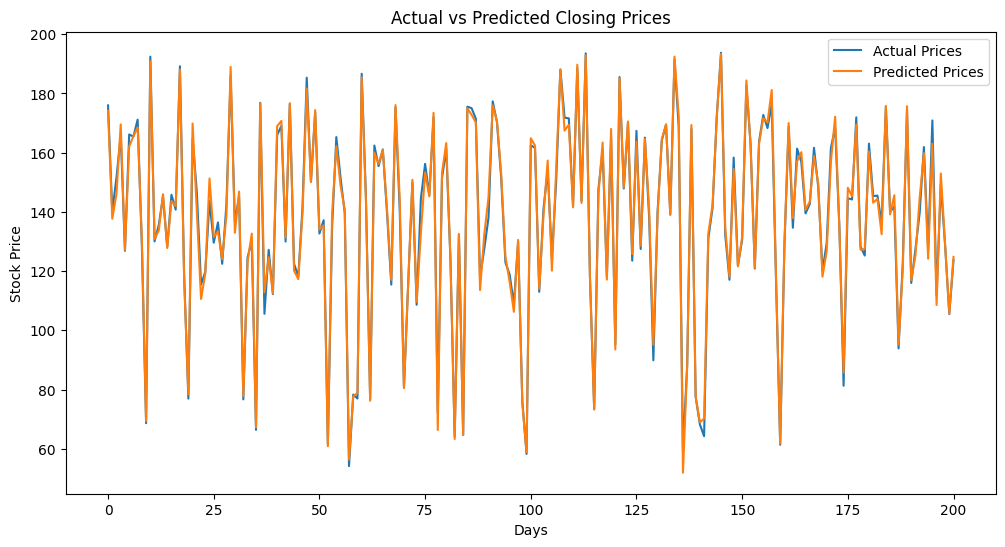

In [14]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Prices")

plt.plot(predictions, label="Predicted Prices")

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.legend()

plt.show()